# Presentation figures — feature sifting

Every figure for the talk, made in one place. The performance figures are the **clean-or-noise** sifting
problem of `feature_sifting_clean_or_noise.ipynb` (plus its corrupted-signal cousin for the last one), and the
weight trajectories are `zero_crossings_vs_step_size.ipynb`, restyled for dark slides.

**How to use it.** Run top to bottom. Each experiment is cached under `data/presentation/` the first time it
runs, so re-running the notebook to restyle takes seconds. A cache entry is discarded automatically when the
settings it was made with change; `FORCE_RERUN` discards one by hand. Every figure is saved to
`output/presentation/` as a PNG, numbered in the order of the figure list.

**What to edit.** The next three cells hold everything cosmetic — titles, colors and labels, sizes — and the
cell after them the problem settings. Nothing further down needs touching to restyle.

**Names, in the talk's terms.** *LMS* is least mean squares at a fixed step-size. *LMSA* is LMS with Autostep
step-sizes. *Cross Zero* prunes a slot the step its weight crosses zero. *L1* adds a subgradient L1 penalty to
the weight update. *Cross CI* prunes a slot whose weight sits inside the confidence band a dead weight of the
same age would occupy (the "band" test of the source notebook). A pruned slot has its feature redrawn.

| # | figure | methods |
|---|---|---|
| 1 | `lms` | LMS |
| 2 | `lmsa` | LMS, LMSA |
| 3 | `cross_zero` | LMSA, LMSA + Cross Zero |
| 4 | `cross_zero_big_step` | … + LMSA + Cross Zero at initial step-size 0.01 |
| 5 | `trajectories` | a dead weight under LMS at several step-sizes |
| 6 | `trajectories_l1` | the same, with LMS + L1 overlaid |
| 7 | `l1_cross_zero` | LMSA, LMSA + Cross Zero, LMSA + L1 + Cross Zero |
| 8 | `all_methods` | … + LMSA + Cross CI |
| 9 | `all_methods_3m` | all four, for 3M steps, on signals of decaying weight |
| 10 | `corrupted` | all four, on the corrupted-signal problem |
| 11 | `coverage_by_size` | the figure 9 runs: how often each signal ends up covered, by its weight |

Every performance figure comes as three PNGs: `_loss`, `_signals` (distinct signals recovered) and
`_replacements` (slots replaced per step).

In [28]:
# ============================== TITLES ==============================
# One entry per saved figure. Keep them short: the text is large, and a long title runs off the plot.
TITLES = {
    # 1. LMS alone
    'lms_loss':                          'LMS',
    'lms_signals':                       'LMS',
    'lms_replacements':                  'LMS',
    # 2. LMS and LMSA
    'lmsa_loss':                         'LMS vs. LMSA',
    'lmsa_signals':                      'LMS vs. LMSA',
    'lmsa_replacements':                 'LMS vs. LMSA',
    # 3. LMSA and LMSA + Cross Zero
    'cross_zero_loss':                   'Cross Zero',
    'cross_zero_signals':                'Cross Zero',
    'cross_zero_replacements':           'Cross Zero',
    # 4. ... and Cross Zero from a large initial step-size
    'cross_zero_big_step_loss':          'Cross Zero: initial step-size',
    'cross_zero_big_step_signals':       'Cross Zero: initial step-size',
    'cross_zero_big_step_replacements':  'Cross Zero: initial step-size',
    # 5, 6. Dead-weight trajectories
    'trajectories':                      'A useless weight under LMS',
    'trajectories_l1':                   'A useless weight under LMS and LMS + L1',
    # 7. ... and L1 + Cross Zero
    'l1_cross_zero_loss':                'L1 + Cross Zero',
    'l1_cross_zero_signals':             'L1 + Cross Zero',
    'l1_cross_zero_replacements':        'L1 + Cross Zero',
    # 8. All methods
    'all_methods_loss':                  'Cross CI',
    'all_methods_signals':               'Cross CI',
    'all_methods_replacements':          'Cross CI',
    # 9. All methods, 3M steps
    'all_methods_3m_loss':               'All methods, 3M steps',
    'all_methods_3m_signals':            'All methods, 3M steps',
    'all_methods_3m_replacements':       'All methods, 3M steps',
    # 10. All methods on corrupted signals
    'corrupted_loss':                    'Corrupted signals',
    'corrupted_signals':                 'Corrupted signals',
    'corrupted_replacements':            'Corrupted signals',
    # 11. Coverage by signal size, 3M steps
    'coverage_by_size':                  'Coverage by signal size',
}

In [29]:
# ============================== COLORS AND LABELS ==============================
BACKGROUND = '#212121'           # Google Slides dark theme
TEXT_COLOR = '#F5F5F5'
MUTED_COLOR = '#9E9E9E'          # axes, ticks, grid
BOUND_COLOR = '#E0E0E0'          # dotted bound lines
TRANSPARENT_BACKGROUND = False   # True saves the PNGs with a transparent background instead of BACKGROUND

# Every plot looks a method's color up here, so a method keeps its color across all figures.
# Switch palettes by uncommenting one block. The four "all methods" are lmsa, cross_zero, l1_cross_zero and
# cross_ci; lms and cross_zero_big_step only appear in the first four figures.
# COLORS = {                       # the palette from the notes, plus two extras; the purple is lifted so it
#     'lms':                 '#7B3AE8',   #   reads on the dark background (the original is #5003C0)
#     'lmsa':                '#C12BC0',   #   (original #AB03A9)
#     'cross_zero':          '#FF467A',
#     'l1_cross_zero':       '#FFD51E',
#     'cross_ci':            '#00E5FF',
#     'cross_zero_big_step': '#3DFF8F',
# }
# COLORS = {                     # the notes' palette exactly as given
#     'lms':                 '#5003C0',
#     'lmsa':                '#AB03A9',
#     'cross_zero':          '#FF467A',
#     'l1_cross_zero':       '#FFD51E',
#     'cross_ci':            '#00E5FF',
#     'cross_zero_big_step': '#3DFF8F',
# }
# COLORS = {                     # neon
#     'lms':                 '#B388FF',
#     'lmsa':                '#F15BB5',
#     'cross_zero':          '#FF6B35',
#     'l1_cross_zero':       '#FEE440',
#     'cross_ci':            '#00F5D4',
#     'cross_zero_big_step': '#00BBF9',
# }
# COLORS = {                     # synthwave
#     'lms':                 '#9D4EDD',
#     'lmsa':                '#FF6EC7',
#     'cross_zero':          '#FF9E00',
#     'l1_cross_zero':       '#FFEA00',
#     'cross_ci':            '#00F0FF',
#     'cross_zero_big_step': '#39FF14',
# }
COLORS = {                     # flat
    'lms':                 '#e67e22',
    'lmsa':                '#2ecc71',
    'cross_zero':          '#9b59b6',
    'l1_cross_zero':       '#3498db',
    'cross_ci':            '#e74c3c',
    'cross_zero_big_step': '#f39c12',
}

LABELS = {
    'lms':                 'LMS',
    'lmsa':                'LMSA',
    'cross_zero':          'LMSA + Cross Zero',
    'cross_zero_big_step': 'LMSA + Cross Zero (init. step-size 0.01)',
    'l1_cross_zero':       'LMSA + L1 + Cross Zero',
    'cross_ci':            'LMSA + Cross CI',
    'lower_bound':         'lower bound',
    'all_signals':         'all signals',
    'trajectory_lms':      'LMS',
    'trajectory_l1':       'LMS + L1',
    'l1_threshold':        'L1 threshold',
}
AXIS_LABELS = {
    'step':         'step (binned)',
    'loss':         'loss',
    'signals':      'signals recovered',
    'replacements': 'replacements per step',
    'weight':       'weight',
    'trajectory_step': 'step',
    'signal_weight':   'signal weight',
    'fraction_runs':   'fraction of runs',
}

In [30]:
# ============================== SIZES AND OUTPUT ==============================
FONT_SIZES = dict(title=22, label=18, tick=15, legend=14, panel_title=17)
FIGSIZE = (8, 5)                 # one performance plot; half a 16:9 slide
TRAJECTORY_FIGSIZE = (14, 8.5)   # the stacked trajectory panels; a full 16:9 slide
DPI = 200
LINE_WIDTH = 2.6
TRAJECTORY_LINE_WIDTH = 1.0
BAND_ALPHA = 0.22                # the +-2 standard error band
LEGEND_LOC = 'best'

LOSS_YLIM = (0.8, 4.6)           # shared by every loss plot so the slides line up; None lets each plot choose
LOSS_YLIM_DECAYING = (0.9, 2.0)  # figure 9: with weights 2^-i the mean predictor sits at 1.44, not 4.33
SHOW_ALL_SIGNALS_LINE = True     # dotted line at the number of signals in the target on the signals plots
SHOW_L1_THRESHOLD_LINE = True    # dotted line at the smallest weight L1 leaves standing, on the coverage-by-size plot
REPLACEMENTS_SMOOTHING = 10      # moving-average window, in bins, for the replacements plot; a single bin
                                 # holds 0 or 1 replacements late in a run, which plots as spikes without it
REPLACEMENTS_LINTHRESH = 1e-4    # the replacements plot is symlog: linear (so zero shows) below this, log above
REPLACEMENTS_YLIM = (0, 5)       # top=None fits the data
REPLACEMENTS_BAND = False        # the +-2 standard error band on the replacements plot; on a log axis a band
                                 # that reaches zero fills the whole space below the line, so it is off by default

from pathlib import Path
# The notebook lives in phd/structure_search/multi_geoff_exploration; this works whether the kernel's working
# directory is that folder (VS Code, jupyter started there) or the repository root.
NOTEBOOK_DIR = Path('phd/structure_search/multi_geoff_exploration') if Path('phd').is_dir() else Path('.')
DATA_DIR = NOTEBOOK_DIR / 'data' / 'presentation'
FIGURE_DIR = NOTEBOOK_DIR / 'output' / 'presentation'
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

FORCE_RERUN = set()              # e.g. {'clean__cross_ci', 'trajectories'}: recompute these even if cached

In [31]:
import json
import os
import time
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, ScalarFormatter
import numpy as np
import optax

from phd.jax_core.optimizers.idbd import optax_idbd, IDBDState
from phd.jax_core.tasks.clean_or_noise_sifting import CleanOrNoiseSiftingTask
from phd.jax_core.tasks.feature_sifting import FeatureSiftingTask
from phd.jax_core.utils import stack_pytrees, tree_replace

%matplotlib inline


def setup_font():
    """Arial to match the slides. It is not a Linux font, but the Windows one is visible from WSL; failing that,
    Liberation Sans has Arial's exact metrics."""
    for directory in ['/mnt/c/Windows/Fonts', 'C:/Windows/Fonts', '/Library/Fonts',
                      os.path.expanduser('~/.fonts')]:
        for name in ['arial.ttf', 'arialbd.ttf', 'ariali.ttf', 'arialbi.ttf']:
            path = os.path.join(directory, name)
            if os.path.exists(path):
                fm.fontManager.addfont(path)
    available = {f.name for f in fm.fontManager.ttflist}
    return next((f for f in ['Arial', 'Liberation Sans', 'DejaVu Sans'] if f in available), 'sans-serif')


FONT_FAMILY = setup_font()
print(f'font: {FONT_FAMILY}')

plt.rcParams.update({
    'font.family': FONT_FAMILY,
    'mathtext.fontset': 'custom', 'mathtext.rm': FONT_FAMILY, 'mathtext.it': f'{FONT_FAMILY}:italic',
    'mathtext.bf': f'{FONT_FAMILY}:bold',
    'figure.facecolor': BACKGROUND, 'axes.facecolor': BACKGROUND, 'savefig.facecolor': BACKGROUND,
    'text.color': TEXT_COLOR, 'axes.labelcolor': TEXT_COLOR,
    'xtick.color': TEXT_COLOR, 'ytick.color': TEXT_COLOR,
    'axes.edgecolor': MUTED_COLOR, 'axes.linewidth': 1.2,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.major.width': 1.2, 'ytick.major.width': 1.2, 'xtick.major.size': 5, 'ytick.major.size': 5,
    'axes.grid': True, 'grid.color': TEXT_COLOR, 'grid.alpha': 0.12, 'grid.linewidth': 0.8,
    'axes.titlesize': FONT_SIZES['title'], 'axes.titleweight': 'bold', 'axes.titlepad': 14,
    'axes.labelsize': FONT_SIZES['label'], 'axes.labelpad': 8,
    'xtick.labelsize': FONT_SIZES['tick'], 'ytick.labelsize': FONT_SIZES['tick'],
    'legend.fontsize': FONT_SIZES['legend'], 'legend.frameon': False, 'legend.handlelength': 2.2,
    'lines.solid_capstyle': 'round',
})

font: Arial


In [32]:
# ============================== PROBLEM ==============================
N_TARGET_FEATURES = 10           # signals the target sums, each uniform on INPUT_BOUNDS with a weight of +-1
N_LEARNER_FEATURES = 10          # candidate slots the learner observes
CLEAN_PROB = 0.01                # clean-or-noise: chance a drawn candidate is an exact copy of a signal
WITH_REPLACEMENT = False         # clean-or-noise: whether two slots may hold copies of the same signal
NOISE_STD = 1.0                  # observation noise on the target
INPUT_BOUNDS = (-1.0, 1.0)
CORRUPTED_SIGNAL_THRESHOLD = 0.25    # corrupted signals: a slot counts as a recovered signal when its noise
                                     # mixing coefficient (0 = exact copy, 1 = pure noise) is below this

# ============================== OPTIMIZERS ==============================
LMS_STEP_SIZE = 0.001
INIT_STEP_SIZE = 1e-10           # Autostep's starting step-size for every slot
BIG_INIT_STEP_SIZE = 0.01        # the alternative in figure 4
META_STEP_SIZE = 0.02
L1_COEFF = 0.01                  # subgradient L1 on the candidate weights
BAND_TRACE_HORIZON = 1_000       # Cross CI: EMA horizon for the residual power E[delta^2]

# ============================== TRAINING ==============================
NUM_STEPS = 200_000
NUM_STEPS_LONG = 3_000_000       # figure 9
NUM_STEPS_CORRUPTED = 1_000_000  # figure 10
DECAY_BASE = 2.0                 # figure 11: signal i has weight +-DECAY_BASE**-i, so 1, 1/2, 1/4, ...
N_SEEDS = 30                     # vmapped into one scan
N_SNAPSHOTS = 200                # bins per run; every recorded series is a mean over its bin
BASE_SEED = 0

# ============================== TRAJECTORIES (figures 5, 6) ==============================
TRAJECTORY_STEPS = 800_000
TRAJECTORY_STEP_SIZES = [1e-2, 1e-4, 1e-8]
TRAJECTORY_GRID = (3, 1)         # rows, cols; must hold len(TRAJECTORY_STEP_SIZES) panels
TRAJECTORY_L1 = L1_COEFF
TRAJECTORY_SEED = 0

# ============================== DERIVED ==============================
N_OUTPUTS = 1                    # one target; the (output, slot) grid shape is kept for the optimizer
N_SLOTS = N_LEARNER_FEATURES + 1 # one weight per candidate, plus a bias column
INPUT_VAR = (INPUT_BOUNDS[1] - INPUT_BOUNDS[0]) ** 2 / 12
IRREDUCIBLE_MSE = NOISE_STD ** 2 # the loss lower bound: every signal covered exactly
TARGET_WEIGHTS_DECAY = DECAY_BASE ** -np.arange(N_TARGET_FEATURES)   # figure 11's signal weights, largest first
L1_THRESHOLD = L1_COEFF / INPUT_VAR                                     # the smallest weight L1 leaves standing

## Learners

Each method is an `eqx.Module` with `init()` and `step(inputs, y)`, carrying the `prune_mask` the task reads to
redraw candidates. A pruned slot is reset to its starting state (zero weight, `INIT_STEP_SIZE`, no traces) on
the step it is cut, and the task swaps in a fresh feature at the top of the next one.

In [33]:
def slot_inputs(inputs):
    """Pad the slot grid with the bias column: a constant-1 input that is never a candidate."""
    return jnp.concatenate([inputs, jnp.ones((N_OUTPUTS, 1))], axis=1)


def linear_loss_and_grads(w, x, y):
    """Squared error, and the LMS gradient `delta * x` (the factor 2 is folded into the step-size)."""
    error = jnp.sum(w * x, axis=-1) - y
    return jnp.sum(error ** 2), error[:, None] * x


def init_autostep(cls, init_step_size, **extra):
    optimizer = optax_idbd(init_lr=init_step_size, meta_lr=META_STEP_SIZE, autostep=True)
    w = jnp.zeros((N_OUTPUTS, N_SLOTS))
    return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
               prune_mask=jnp.zeros((N_OUTPUTS, N_LEARNER_FEATURES), dtype=bool), **extra)


def reset_pruned(w, opt_state, prune_mask):
    """Return every slot just cut to its starting state, so a fresh candidate inherits no history."""
    pruned = jnp.pad(prune_mask, ((0, 0), (0, 1)))     # the bias column is never pruned
    return jnp.where(pruned, 0.0, w), IDBDState(
        init_beta=opt_state.init_beta,
        beta=jnp.where(pruned, opt_state.init_beta, opt_state.beta),
        h=jnp.where(pruned, 0.0, opt_state.h),
        v=jnp.where(pruned, 0.0, opt_state.v),
    )


class LMS(eqx.Module):
    """Least mean squares at a fixed step-size on the initial pool; never prunes."""
    w: jax.Array
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        return cls(w=jnp.zeros((N_OUTPUTS, N_SLOTS)),
                   prune_mask=jnp.zeros((N_OUTPUTS, N_LEARNER_FEATURES), dtype=bool))

    def step(self, inputs, y):
        x = slot_inputs(inputs)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        return tree_replace(self, w=self.w - LMS_STEP_SIZE * grads), loss


class LMSA(eqx.Module):
    """LMS with Autostep: a step-size per slot, but no pruning."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls, init_step_size=INIT_STEP_SIZE):
        return init_autostep(cls, init_step_size)

    def step(self, inputs, y):
        x = slot_inputs(inputs)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        # Autostep takes the loss gradient and the prediction gradient (= x for a linear model).
        updates, opt_state = self.optimizer.update((grads, x), self.opt_state, self.w)
        return tree_replace(self, w=self.w + updates, opt_state=opt_state), loss


class LMSACrossZero(eqx.Module):
    """LMSA + Cross Zero: a slot is cut the step its weight crosses zero.

    With `l1 > 0` the subgradient `l1 * sign(w)` joins the loss gradient, so it drives the weight update and
    Autostep's step-size adaptation alike. It pulls a dead weight back across zero at a rate that does not
    vanish with the step-size, which is what keeps the test firing from a tiny `INIT_STEP_SIZE`.
    """
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    l1: float = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls, l1=0.0, init_step_size=INIT_STEP_SIZE):
        return init_autostep(cls, init_step_size, l1=l1)

    def step(self, inputs, y):
        x = slot_inputs(inputs)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        if self.l1:
            # L1 on the candidates only; `loss` stays pure squared error so the curves stay comparable.
            grads = grads + self.l1 * jnp.sign(self.w).at[:, -1].set(0.0)
        updates, opt_state = self.optimizer.update((grads, x), self.opt_state, self.w)
        w = self.w + updates
        prune_mask = (self.w * w < 0.0)[:, :N_LEARNER_FEATURES]     # the bias is not a candidate
        w, opt_state = reset_pruned(w, opt_state, prune_mask)
        return tree_replace(self, w=w, opt_state=opt_state, prune_mask=prune_mask), loss


class LMSACrossCI(eqx.Module):
    """LMSA + Cross CI: a slot is cut once its weight is inside the confidence band of a dead slot of the
    same age.

    A dead weight is a mean-reverting walk with stationary one-sigma band `sqrt(alpha E[delta^2] / 2)`; a
    weight `t` steps old has only reached `sqrt(1 - rho^t)` of it, `rho = E[(1 - alpha x^2)^2]`. A useful
    weight's mean grows linearly and clears the band in a few hundred steps regardless of `alpha`. The
    maturity is kept as `log(1 - m_t)` because the direct form freezes at zero in float32 for tiny `alpha`.
    """
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    v: jax.Array          # (n_outputs, 1) EMA of the output's squared residual
    v_weight: jax.Array   # accumulated EMA gain, so `v` reads unbiased from step 1
    log_imm: jax.Array    # (n_outputs, n_slots) log(1 - maturity): 0 at birth, -inf once mature
    prune_mask: jax.Array

    @classmethod
    def init(cls, init_step_size=INIT_STEP_SIZE):
        return init_autostep(cls, init_step_size, v=jnp.zeros((N_OUTPUTS, 1)), v_weight=jnp.zeros(()),
                             log_imm=jnp.zeros((N_OUTPUTS, N_SLOTS)))

    def step(self, inputs, y):
        x = slot_inputs(inputs)
        error = jnp.sum(self.w * x, axis=-1) - y
        loss, grads = jnp.sum(error ** 2), error[:, None] * x
        updates, opt_state = self.optimizer.update((grads, x), self.opt_state, self.w)
        w = self.w + updates

        gain = 1.0 / BAND_TRACE_HORIZON
        v = self.v + gain * (error[:, None] ** 2 - self.v)
        v_weight = self.v_weight + gain * (1.0 - self.v_weight)

        # The band for the pre-update age of the weight, then the age advances.
        alpha = jnp.exp(opt_state.beta)
        band = jnp.sqrt(alpha * (v / v_weight) / 2.0 * -jnp.expm1(self.log_imm))
        log_imm = self.log_imm + 2.0 * jnp.log1p(-alpha * x ** 2)

        prune_mask = (jnp.abs(w) < band)[:, :N_LEARNER_FEATURES]
        w, opt_state = reset_pruned(w, opt_state, prune_mask)
        log_imm = jnp.where(jnp.pad(prune_mask, ((0, 0), (0, 1))), 0.0, log_imm)   # a redraw restarts the warm-up
        return tree_replace(self, w=w, opt_state=opt_state, v=v, v_weight=v_weight,
                            log_imm=log_imm, prune_mask=prune_mask), loss


# `config` is what the cache checks: change a method's settings and its cached runs are redone.
METHODS = {
    'lms':                 dict(make=LMS.init,
                                config=dict(step_size=LMS_STEP_SIZE)),
    'lmsa':                dict(make=LMSA.init,
                                config=dict(init_step_size=INIT_STEP_SIZE, meta=META_STEP_SIZE)),
    'cross_zero':          dict(make=LMSACrossZero.init,
                                config=dict(init_step_size=INIT_STEP_SIZE, meta=META_STEP_SIZE)),
    'cross_zero_big_step': dict(make=partial(LMSACrossZero.init, init_step_size=BIG_INIT_STEP_SIZE),
                                config=dict(init_step_size=BIG_INIT_STEP_SIZE, meta=META_STEP_SIZE)),
    'l1_cross_zero':       dict(make=partial(LMSACrossZero.init, l1=L1_COEFF),
                                config=dict(init_step_size=INIT_STEP_SIZE, meta=META_STEP_SIZE, l1=L1_COEFF)),
    'cross_ci':            dict(make=LMSACrossCI.init,
                                config=dict(init_step_size=INIT_STEP_SIZE, meta=META_STEP_SIZE,
                                            horizon=BAND_TRACE_HORIZON)),
}
ALL_METHODS = ['lmsa', 'cross_zero', 'l1_cross_zero', 'cross_ci']

## Problems, training and caching

Two problems share the learners. In the **clean-or-noise** problem a drawn candidate is an exact copy of a signal
with probability `CLEAN_PROB` and an independent draw otherwise, so a signal is *recovered* when some slot holds
a copy of it. In the **corrupted-signal** problem every candidate is a view of a random signal mixed with noise
by a coefficient uniform on [0, 1], so nothing is ever exact; a signal counts as recovered when some slot's
coefficient is below `CORRUPTED_SIGNAL_THRESHOLD`. Both record, per bin, the mean loss, the mean number of
slots replaced per step, and the mean recovered-indicator of each signal.

In [34]:
def make_clean_task(seed):
    return CleanOrNoiseSiftingTask(
        n_target_features=N_TARGET_FEATURES, n_learner_features=N_LEARNER_FEATURES,
        clean_prob=CLEAN_PROB, with_replacement=WITH_REPLACEMENT, target_noise_std=NOISE_STD,
        input_bounds=INPUT_BOUNDS, key=jax.random.PRNGKey(seed))


def clean_recovered(task):
    """Which signals have an exact copy among the slots."""
    return task.covered.astype(jnp.float32)


def make_decaying_task(seed):
    """The clean-or-noise task with the target's unit weights scaled to +-DECAY_BASE**-i, signs kept."""
    task = make_clean_task(seed)
    return tree_replace(task, weights=task.weights * TARGET_WEIGHTS_DECAY)


def make_corrupted_task(seed):
    return FeatureSiftingTask(
        n_target_features=N_TARGET_FEATURES, n_learner_features=N_LEARNER_FEATURES,
        target_noise_std=NOISE_STD, key=jax.random.PRNGKey(seed))


def corrupted_recovered(task):
    """Which signals have a slot whose noise coefficient is below the threshold (1 = no slot points at it)."""
    best = jnp.ones(N_TARGET_FEATURES).at[task.learner_feature_idxs].min(task.noise_coefficients)
    return (best < CORRUPTED_SIGNAL_THRESHOLD).astype(jnp.float32)


PROBLEMS = {
    'clean':     dict(make_task=make_clean_task, recovered=clean_recovered, num_steps=NUM_STEPS,
                      config=dict(clean_prob=CLEAN_PROB, with_replacement=WITH_REPLACEMENT)),
    'decaying_3m': dict(make_task=make_decaying_task, recovered=clean_recovered, num_steps=NUM_STEPS_LONG,
                        config=dict(clean_prob=CLEAN_PROB, with_replacement=WITH_REPLACEMENT,
                                    weights=TARGET_WEIGHTS_DECAY.tolist())),
    'corrupted': dict(make_task=make_corrupted_task, recovered=corrupted_recovered, num_steps=NUM_STEPS_CORRUPTED,
                      config=dict(threshold=CORRUPTED_SIGNAL_THRESHOLD)),
}
SHARED_CONFIG = dict(n_target=N_TARGET_FEATURES, n_learner=N_LEARNER_FEATURES, noise_std=NOISE_STD,
                     input_bounds=INPUT_BOUNDS, n_seeds=N_SEEDS, n_snapshots=N_SNAPSHOTS, base_seed=BASE_SEED)


def train(learner, task, block_len, recovered):
    """Online training in `N_SNAPSHOTS` bins of `block_len` steps, one row of bin means per bin."""
    def one_step(carry, _):
        learner, task = carry
        task, (inputs, y) = task.step(learner.prune_mask[0])   # the task redraws what was cut last step
        learner, loss = learner.step(inputs[None, :], jnp.reshape(y, ()))
        return (learner, task), (loss, jnp.sum(learner.prune_mask), recovered(task))

    def block(carry, _):
        carry, per_step = jax.lax.scan(one_step, carry, length=block_len)
        return carry, jax.tree.map(lambda s: s.mean(0), per_step)

    _, out = jax.lax.scan(block, (learner, task), length=N_SNAPSHOTS)
    return out


def run(method_key, problem_key):
    """`N_SEEDS` independent runs, a fresh teacher and pool each, in one vmapped scan."""
    problem, method = PROBLEMS[problem_key], METHODS[method_key]
    block_len = problem['num_steps'] // N_SNAPSHOTS
    tasks = stack_pytrees([problem['make_task'](BASE_SEED + s) for s in range(N_SEEDS)])
    fn = jax.jit(jax.vmap(lambda task: train(method['make'](), task, block_len, problem['recovered'])))
    loss, replacements, signals = fn(tasks)
    return {'steps': np.arange(1, N_SNAPSHOTS + 1) * block_len,
            'loss': np.asarray(loss),                  # (seeds, bins)
            'replacements': np.asarray(replacements),  # (seeds, bins) slots replaced per step
            'signals': np.asarray(signals)}            # (seeds, bins, signals) fraction of the bin recovered


def cached(name, signature, compute):
    """Load `name` from the cache when it exists and was made with `signature`; otherwise compute and save."""
    path = DATA_DIR / f'{name}.npz'
    if path.exists() and name not in FORCE_RERUN:
        with np.load(path) as f:
            if str(f['signature']) == signature:
                return {k: f[k] for k in f.files if k != 'signature'}
        print(f'{name}: cache was made with different settings, recomputing')
    print(f'{name}: computing...', end=' ', flush=True)
    start = time.time()
    out = compute()
    np.savez(path, signature=signature, **out)
    print(f'{time.time() - start:.0f}s')
    return out


def results_for(method_key, problem_key):
    problem = PROBLEMS[problem_key]
    signature = json.dumps({**SHARED_CONFIG, 'num_steps': problem['num_steps'], 'problem': problem['config'],
                            'method': METHODS[method_key]['config']}, sort_keys=True, default=str)
    return cached(f'{problem_key}__{method_key}', signature, lambda: run(method_key, problem_key))

## Plotting

In [35]:
def line(ax, x, y, color, label=None, lw=LINE_WIDTH, **kw):
    return ax.plot(x, y, color=color, lw=lw, label=label, **kw)[0]


def mean_and_band(ax, x, series, color, label, band=True):
    """Mean over seeds with a +-2 standard error band."""
    mean = series.mean(0)
    if band:
        sem = series.std(0) / np.sqrt(series.shape[0])
        ax.fill_between(x, mean - 2 * sem, mean + 2 * sem, color=color, alpha=BAND_ALPHA, lw=0)
    line(ax, x, mean, color, label)


def smooth(series, window):
    """Centered moving average along the last axis; the window shrinks at the edges instead of padding."""
    if window <= 1:
        return series
    kernel = np.ones(window)
    total = np.apply_along_axis(lambda s: np.convolve(s, kernel, 'same'), -1, series)
    count = np.convolve(np.ones(series.shape[-1]), kernel, 'same')
    return total / count


def bound(ax, y, label):
    ax.axhline(y, color=BOUND_COLOR, ls=(0, (2, 2.5)), lw=2, label=label)


def step_axis(ax, last_step, xlabel=AXIS_LABELS['step']):
    """Steps from 0 to `last_step`, ticked as 50k, 1M, ... Call it after plotting: it fixes the limits."""
    def fmt(x, _):
        if x >= 1e6:
            return f'{x / 1e6:g}M'
        if x >= 1e3:
            return f'{x / 1e3:g}k'
        return f'{x:g}'
    ax.xaxis.set_major_formatter(FuncFormatter(fmt))
    ax.set_xlabel(xlabel)
    ax.set_xlim(0, last_step)


def new_figure(title, ylabel):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    return fig, ax


def save(fig, name, rect=None):
    fig.tight_layout(rect=rect)
    path = FIGURE_DIR / f'{name}.png'
    fig.savefig(path, dpi=DPI, transparent=TRANSPARENT_BACKGROUND)
    plt.show()
    print(f'saved {path}')


def performance_figures(number, name, method_keys, problem_key, loss_ylim=LOSS_YLIM):
    """The three plots of one performance figure: loss, distinct signals recovered, replacements per step."""
    results = {m: results_for(m, problem_key) for m in method_keys}
    prefix = f'{number:02d}_{name}'
    last_step = PROBLEMS[problem_key]['num_steps']

    fig, ax = new_figure(TITLES[f'{name}_loss'], AXIS_LABELS['loss'])
    for m, res in results.items():
        mean_and_band(ax, res['steps'], res['loss'], COLORS[m], LABELS[m])
    bound(ax, IRREDUCIBLE_MSE, LABELS['lower_bound'])
    if loss_ylim:
        ax.set_ylim(*loss_ylim)
    step_axis(ax, last_step)
    ax.legend(loc=LEGEND_LOC)
    save(fig, f'{prefix}_loss')

    fig, ax = new_figure(TITLES[f'{name}_signals'], AXIS_LABELS['signals'])
    for m, res in results.items():
        mean_and_band(ax, res['steps'], res['signals'].sum(-1), COLORS[m], LABELS[m])
    if SHOW_ALL_SIGNALS_LINE:
        bound(ax, N_TARGET_FEATURES, LABELS['all_signals'])
    ax.set_ylim(0, N_TARGET_FEATURES * 1.12)
    step_axis(ax, last_step)
    ax.legend(loc=LEGEND_LOC)
    save(fig, f'{prefix}_signals')

    fig, ax = new_figure(TITLES[f'{name}_replacements'], AXIS_LABELS['replacements'])
    top = REPLACEMENTS_YLIM[1]
    for m, res in results.items():
        rate = smooth(res['replacements'], REPLACEMENTS_SMOOTHING)
        mean_and_band(ax, res['steps'], rate, COLORS[m], LABELS[m], band=REPLACEMENTS_BAND)
        top = top if REPLACEMENTS_YLIM[1] is not None else max(top or 0, 1.6 * rate.mean(0).max())
    # Rates span orders of magnitude and some methods never replace anything, so: log above a small
    # threshold, linear (through zero) below it.
    ax.set_yscale('symlog', linthresh=REPLACEMENTS_LINTHRESH, linscale=0.6)
    ax.set_ylim(REPLACEMENTS_YLIM[0], top)
    step_axis(ax, last_step)
    ax.legend(loc=LEGEND_LOC)
    save(fig, f'{prefix}_replacements')
    return results

## Figures 1–4, 7, 8: the clean-or-noise problem at 200k steps

Six methods, each cached once; every figure is a subset of them. The first run of this cell takes a few
minutes; after that it is instant.

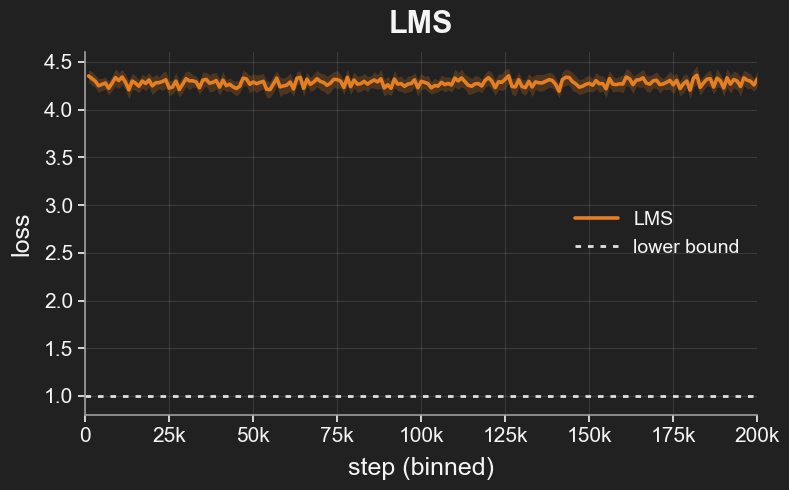

saved output/presentation/01_lms_loss.png


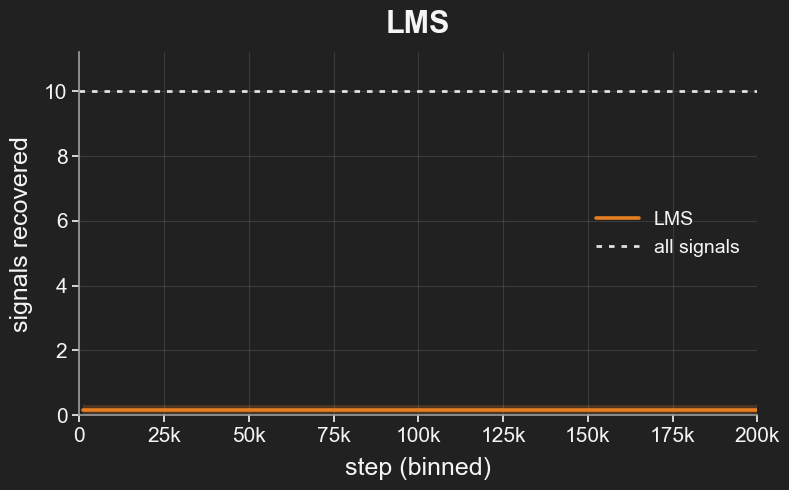

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


saved output/presentation/01_lms_signals.png


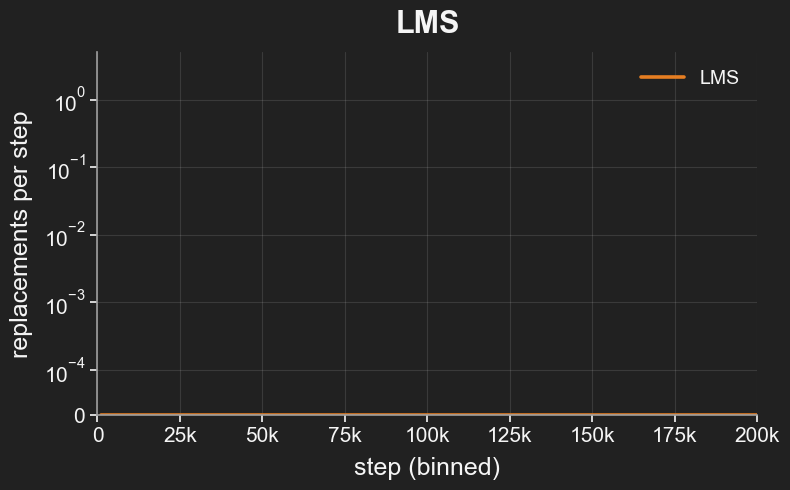

saved output/presentation/01_lms_replacements.png


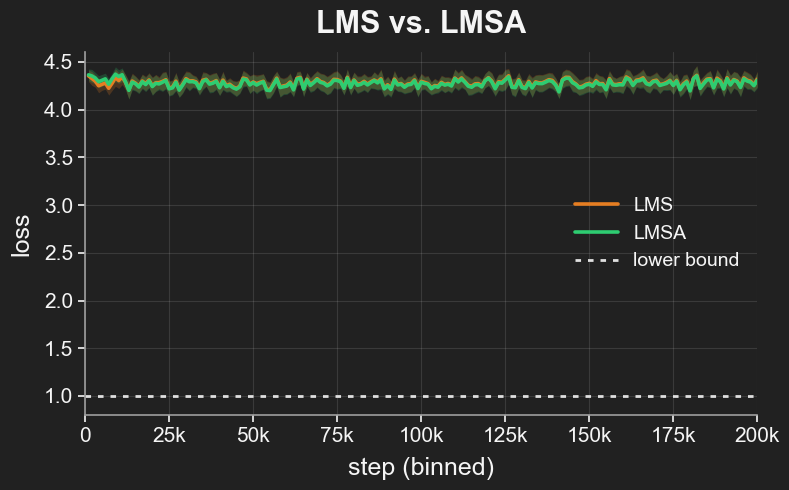

saved output/presentation/02_lmsa_loss.png


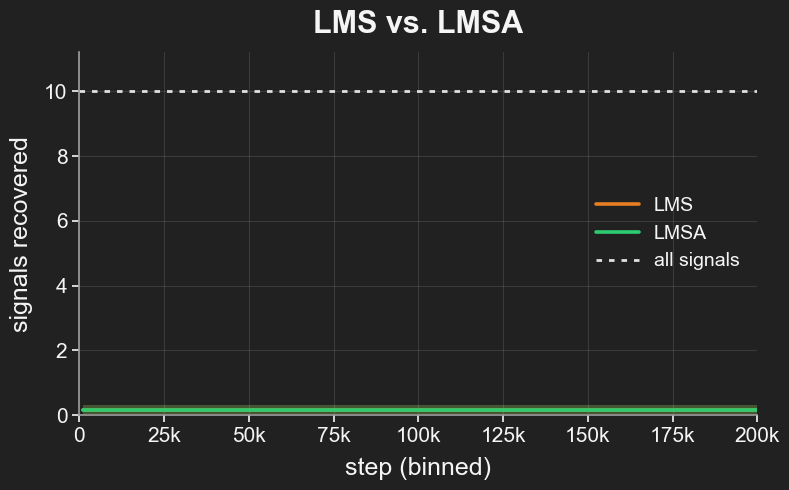

saved output/presentation/02_lmsa_signals.png


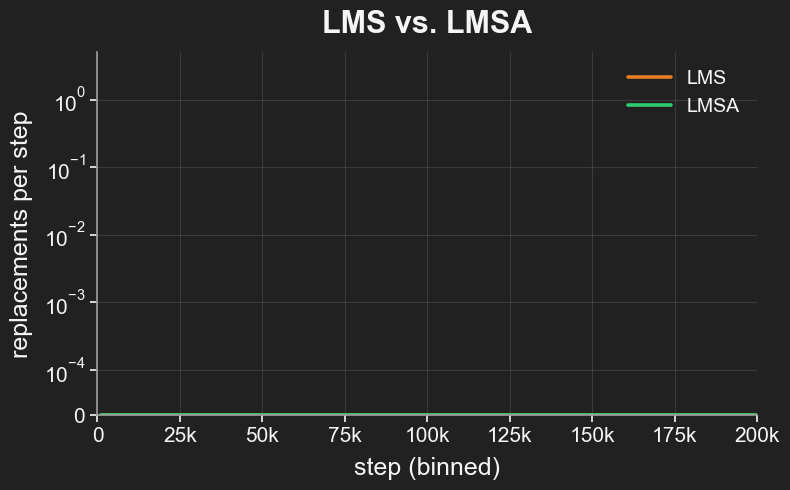

saved output/presentation/02_lmsa_replacements.png


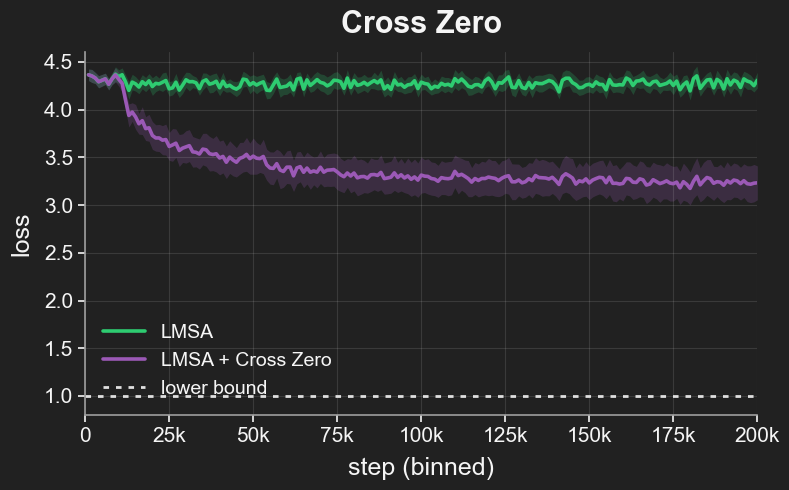

saved output/presentation/03_cross_zero_loss.png


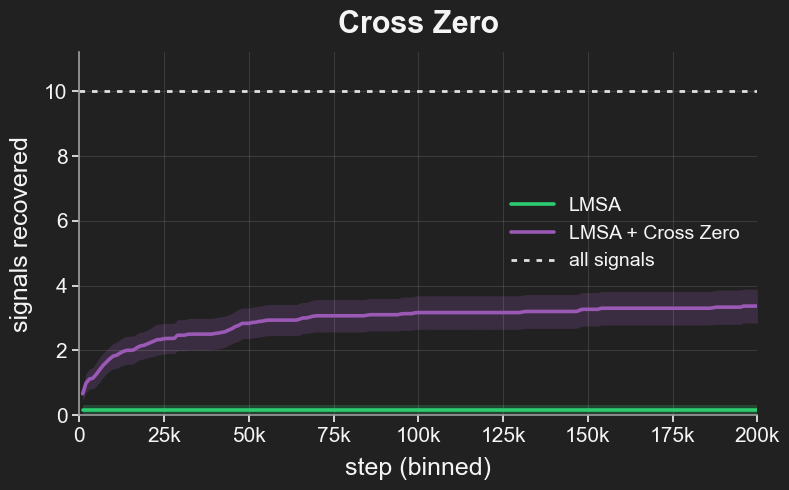

saved output/presentation/03_cross_zero_signals.png


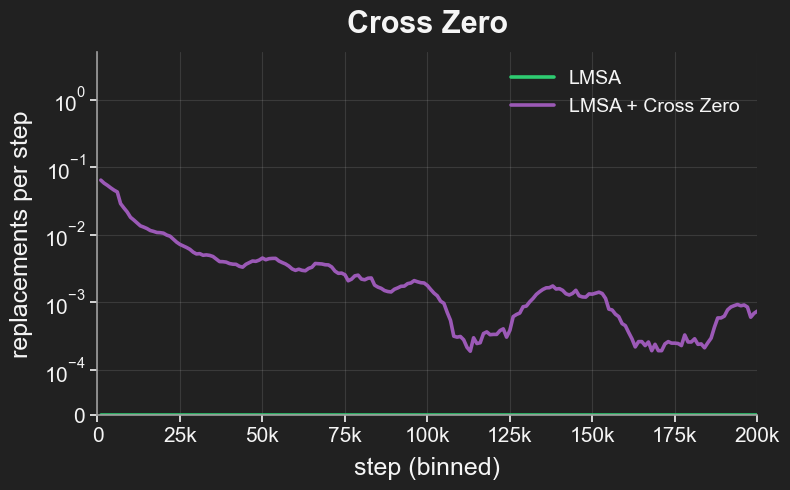

saved output/presentation/03_cross_zero_replacements.png


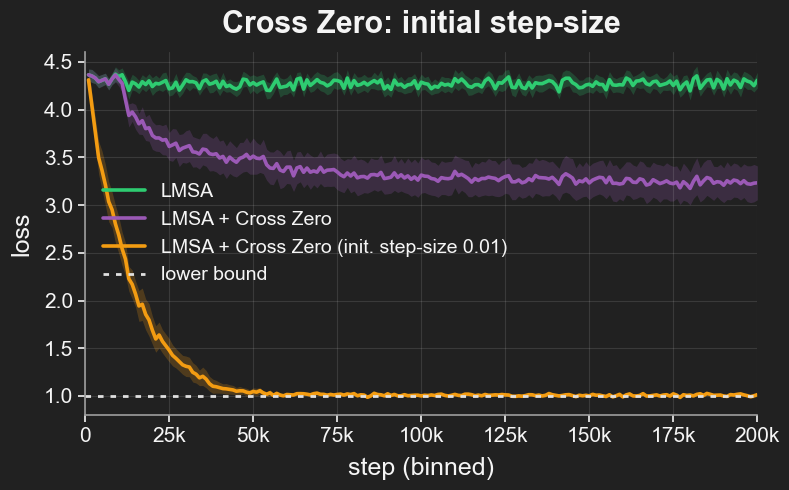

saved output/presentation/04_cross_zero_big_step_loss.png


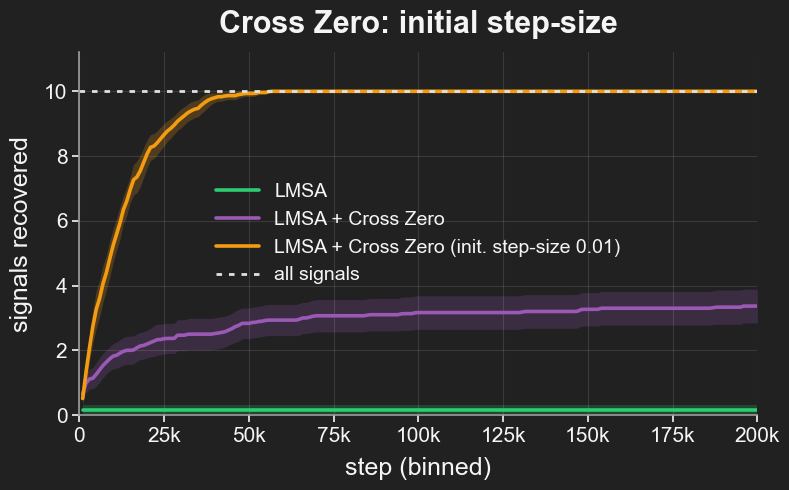

saved output/presentation/04_cross_zero_big_step_signals.png


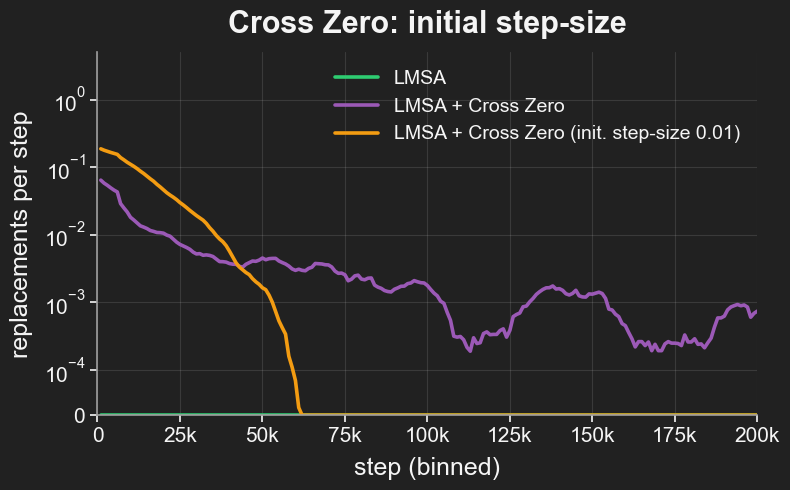

saved output/presentation/04_cross_zero_big_step_replacements.png


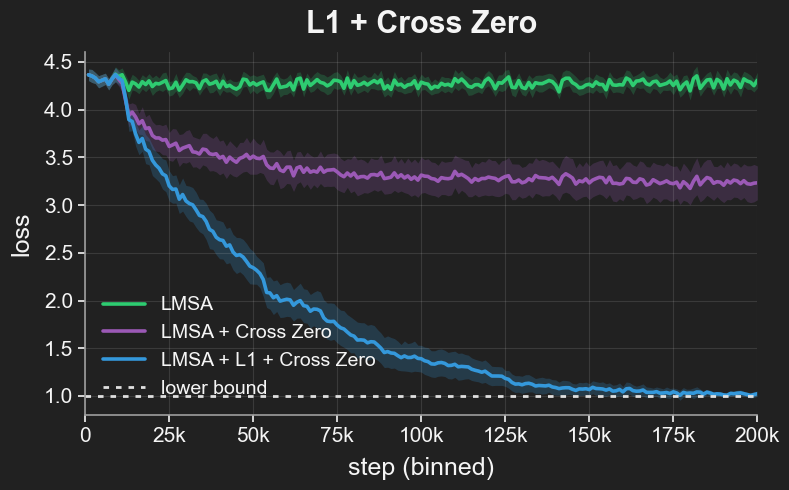

saved output/presentation/07_l1_cross_zero_loss.png


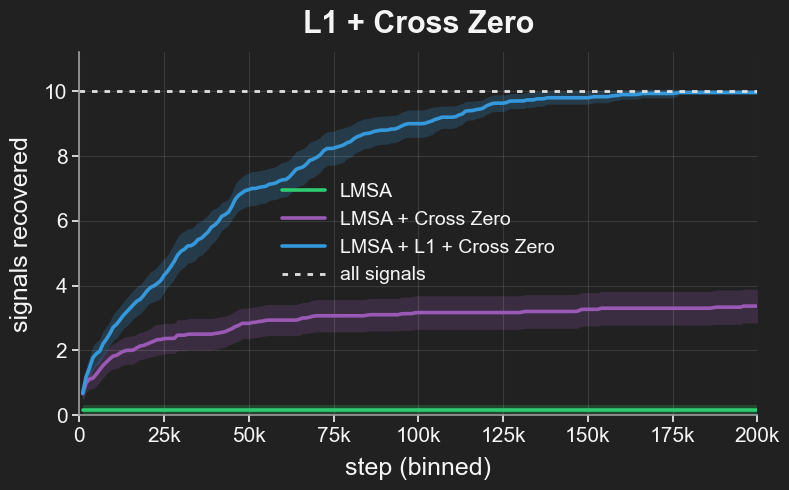

saved output/presentation/07_l1_cross_zero_signals.png


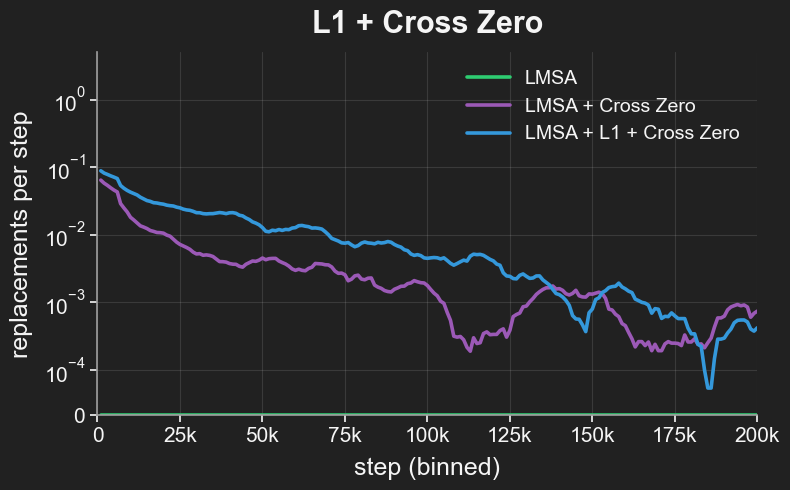

saved output/presentation/07_l1_cross_zero_replacements.png


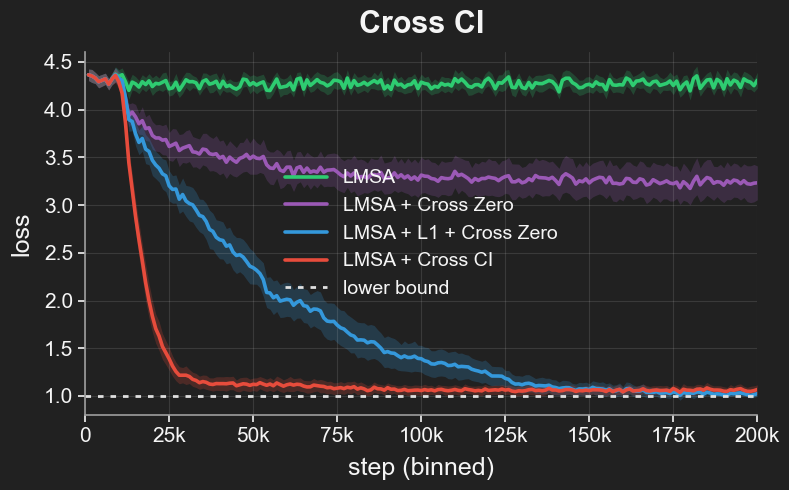

saved output/presentation/08_all_methods_loss.png


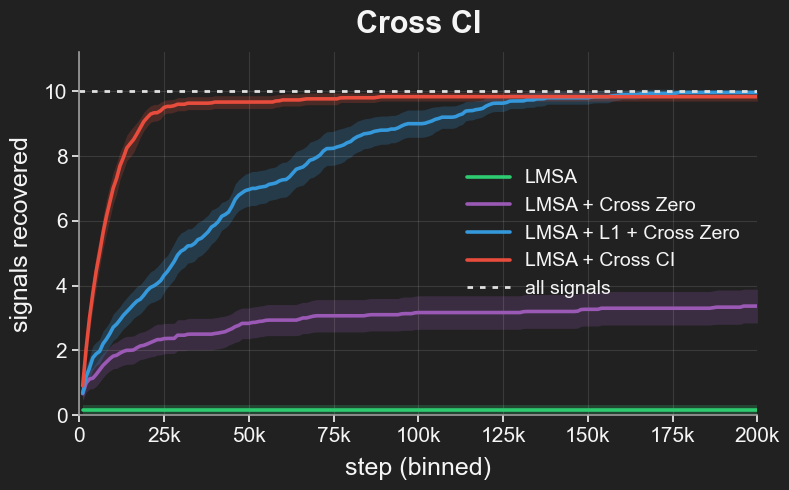

saved output/presentation/08_all_methods_signals.png


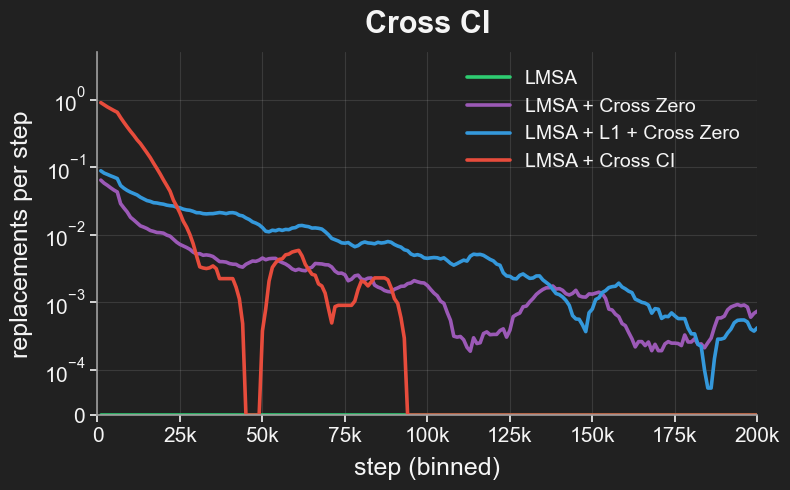

saved output/presentation/08_all_methods_replacements.png


In [36]:
CLEAN_FIGURES = [
    # number, name, methods
    (1, 'lms',                 ['lms']),
    (2, 'lmsa',                ['lms', 'lmsa']),
    (3, 'cross_zero',          ['lmsa', 'cross_zero']),
    (4, 'cross_zero_big_step', ['lmsa', 'cross_zero', 'cross_zero_big_step']),
    (7, 'l1_cross_zero',       ['lmsa', 'cross_zero', 'l1_cross_zero']),
    (8, 'all_methods',         ALL_METHODS),
]
for number, name, methods in CLEAN_FIGURES:
    performance_figures(number, name, methods, 'clean')

## Figures 5, 6: a useless weight at different step-sizes

One weight on an input and a target that are independent standard normals, so the best weight is exactly 0.
Plain LMS pulls it back at a *rate* of `alpha`, so at a small step-size the weight wanders for `1/alpha` steps
without ever crossing zero to be tested. The L1 pull `alpha * lambda` is a fixed *velocity* that does not shrink
as the weight approaches zero, so every step-size settles and crosses at the same period, differing only in
amplitude. Both use the same data stream, so the second figure overlays exactly onto the first.

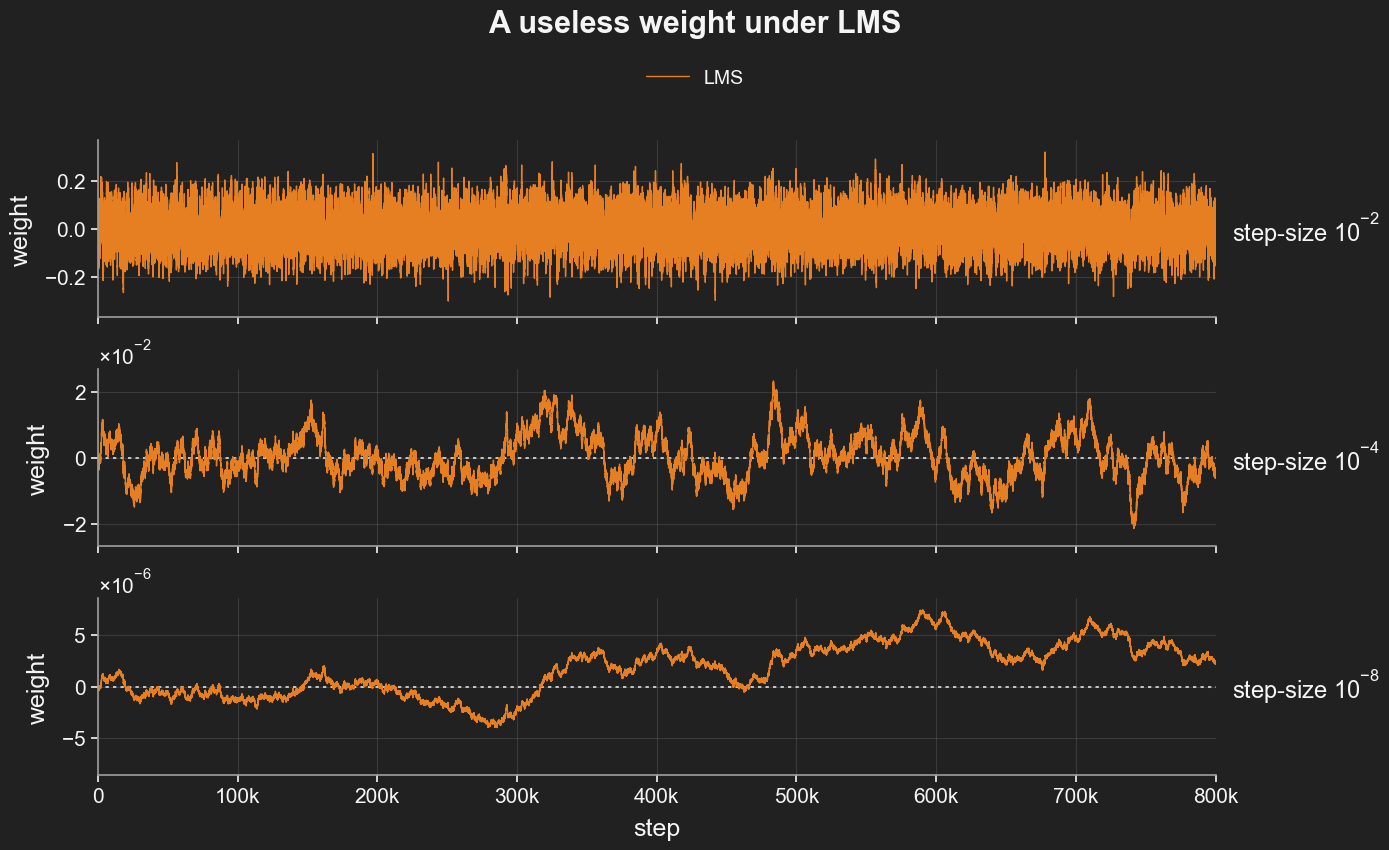

saved output/presentation/05_trajectories.png


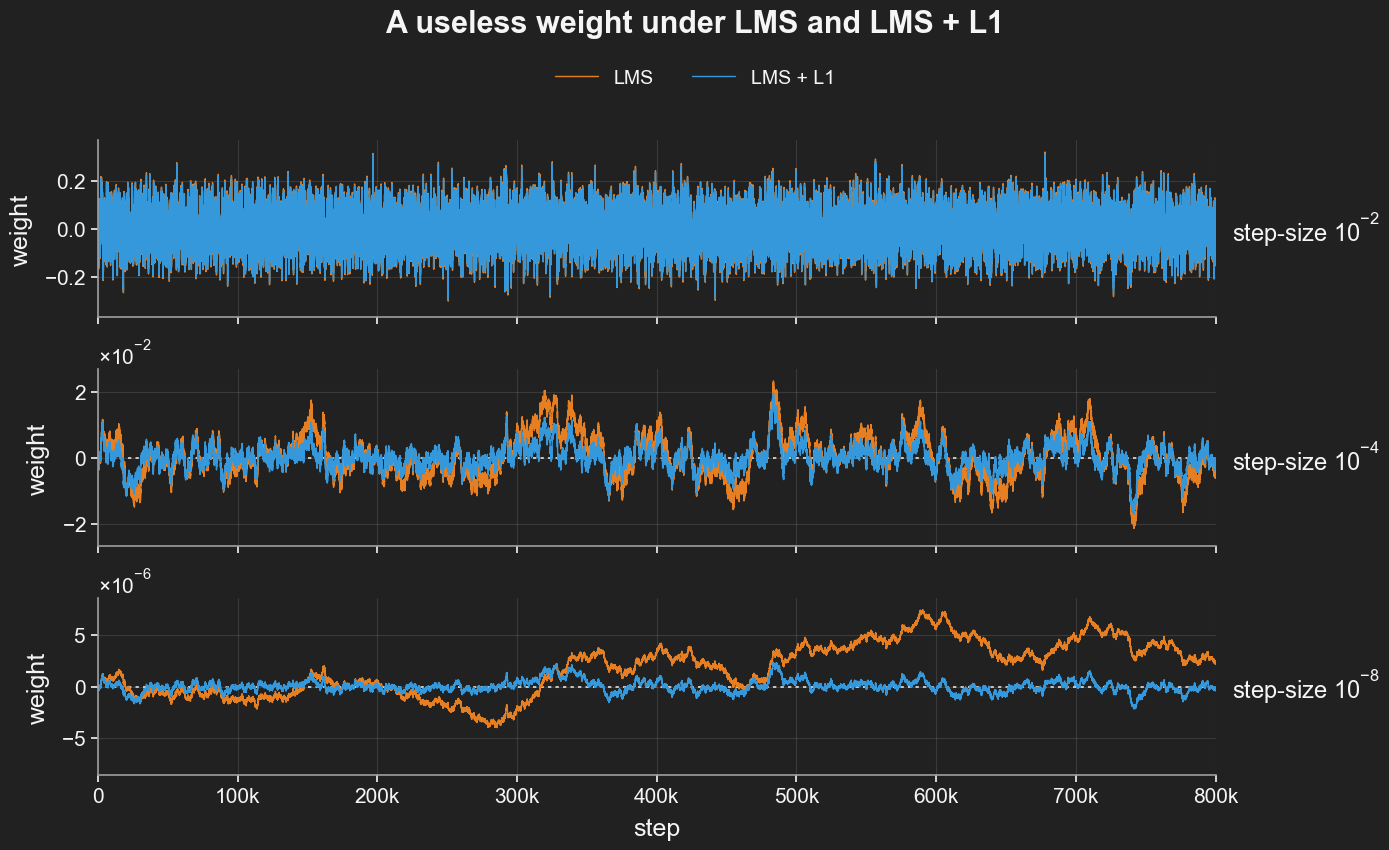

saved output/presentation/06_trajectories_l1.png


In [37]:
def simulate_trajectories(lam):
    rng = np.random.default_rng(TRAJECTORY_SEED)
    x = rng.standard_normal(TRAJECTORY_STEPS)
    y = rng.standard_normal(TRAJECTORY_STEPS)
    alphas = np.asarray(TRAJECTORY_STEP_SIZES)
    w = np.zeros(len(alphas))
    history = np.empty((TRAJECTORY_STEPS, len(alphas)))
    for t in range(TRAJECTORY_STEPS):
        w -= alphas * ((w * x[t] - y[t]) * x[t] + lam * np.sign(w))
        history[t] = w
    return history


trajectories = cached(
    'trajectories',
    json.dumps(dict(steps=TRAJECTORY_STEPS, step_sizes=TRAJECTORY_STEP_SIZES, l1=TRAJECTORY_L1,
                    seed=TRAJECTORY_SEED)),
    lambda: {'lms': simulate_trajectories(0.0), 'l1': simulate_trajectories(TRAJECTORY_L1)})


def trajectory_figure(number, name, with_l1):
    rows, cols = TRAJECTORY_GRID
    fig, axes = plt.subplots(rows, cols, figsize=TRAJECTORY_FIGSIZE, sharex=True, squeeze=False)
    steps = np.arange(1, TRAJECTORY_STEPS + 1)
    for ax, alpha, w_lms, w_l1 in zip(axes.ravel(), TRAJECTORY_STEP_SIZES,
                                      trajectories['lms'].T, trajectories['l1'].T):
        ax.axhline(0, color=BOUND_COLOR, ls=(0, (2, 2.5)), lw=1.2)
        line(ax, steps, w_lms, COLORS['lms'], LABELS['trajectory_lms'], lw=TRAJECTORY_LINE_WIDTH)
        if with_l1:
            line(ax, steps, w_l1, COLORS['l1_cross_zero'], LABELS['trajectory_l1'], lw=TRAJECTORY_LINE_WIDTH)
        # The y-limits come from the LMS trace alone, so the two figures overlay exactly.
        limit = 1.15 * np.abs(w_lms).max()
        ax.set_ylim(-limit, limit)
        # Small weights are ticked as 2.5, 5 with a x10^-6 note rather than as a string of zeros.
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 3))
        ax.yaxis.get_offset_text().set_fontsize(FONT_SIZES['tick'])
        # The step-size is written to the right of the panel, where it can never sit on the trace and costs
        # the stacked panels no height.
        ax.annotate(f'step-size $10^{{{round(np.log10(alpha))}}}$', xy=(1, 0.5), xycoords='axes fraction',
                    xytext=(12, 0), textcoords='offset points', ha='left', va='center',
                    fontsize=FONT_SIZES['panel_title'], annotation_clip=False)
        step_axis(ax, TRAJECTORY_STEPS, xlabel=None)
    for ax in axes[-1]:
        ax.set_xlabel(AXIS_LABELS['trajectory_step'])
    for ax in axes[:, 0]:
        ax.set_ylabel(AXIS_LABELS['weight'])
    # One legend for the whole grid, between the title and the panels, where it covers no data.
    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.945), ncol=len(handles))
    fig.suptitle(TITLES[name], fontsize=FONT_SIZES['title'], fontweight='bold', y=0.995)
    save(fig, f'{number:02d}_{name}', rect=(0, 0, 1, 0.91))   # the top strip holds the title and legend





trajectory_figure(5, 'trajectories', with_l1=False)
trajectory_figure(6, 'trajectories_l1', with_l1=True)

## Figure 9: all methods for 3M steps, on signals of decaying weight

The clean-or-noise problem with the target's weights set to $\pm 2^{-i}$ instead of $\pm 1$: the first signal
is worth 1, the second 1/2, down to about 0.002 for the tenth. Small signals are slow to find, hence the long
run. The loss says much less here than with unit weights: a missing $2^{-9}$ signal costs about $10^{-6}$, so
the mean predictor sits at 1.44 rather than 4.33 and the loss plot has its own y-limits, `LOSS_YLIM_DECAYING`.
A few minutes per method on the first pass.

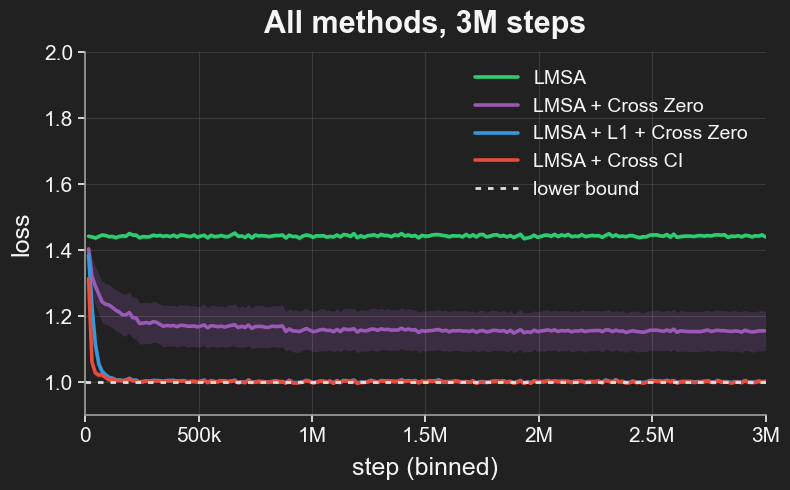

saved output/presentation/09_all_methods_3m_loss.png


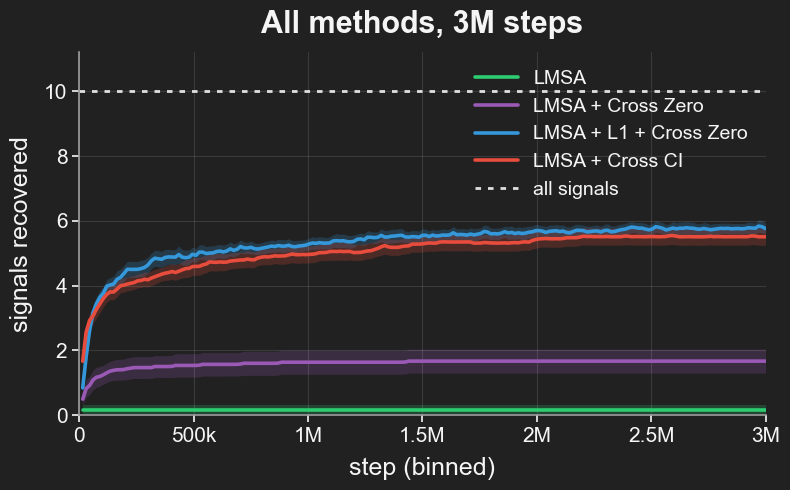

saved output/presentation/09_all_methods_3m_signals.png


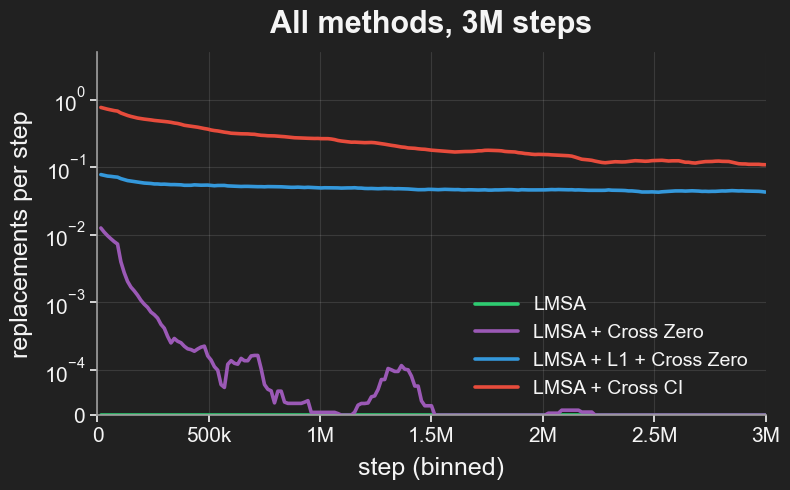

saved output/presentation/09_all_methods_3m_replacements.png


In [38]:
performance_figures(9, 'all_methods_3m', ALL_METHODS, 'decaying_3m', loss_ylim=LOSS_YLIM_DECAYING);

## Figure 10: all methods on corrupted signals

The original `FeatureSiftingTask`: every candidate is a view of a random signal mixed with noise by a
coefficient uniform on [0, 1], so candidates form a continuum of partial views rather than a coin flip. The loss
lower bound is still the observation noise, though no method can reach it here, since an exact copy has
probability zero.

Two things to know when reading it. A signal counts as *recovered* when some slot's noise coefficient is below
`CORRUPTED_SIGNAL_THRESHOLD`, which is a choice rather than a fact of the problem. And every candidate here
carries *some* signal, so every weight has a non-zero best value: the three tests, which all ask whether a
weight is dead, fire only in the first few thousand steps and hardly at all afterwards.

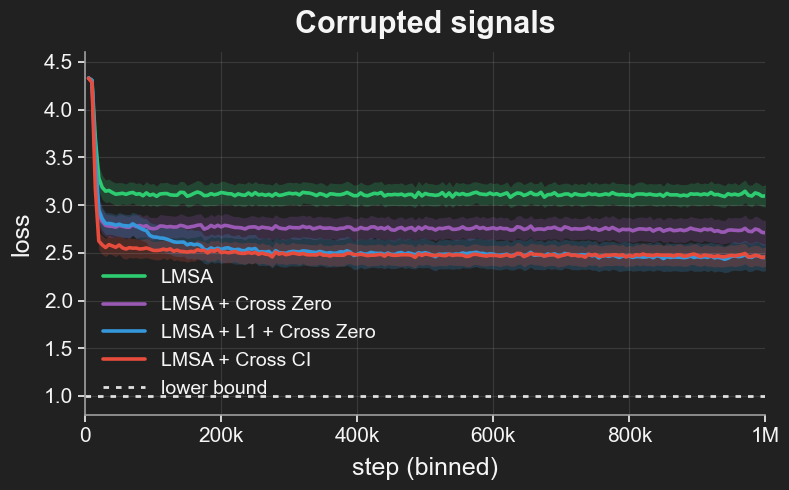

saved output/presentation/10_corrupted_loss.png


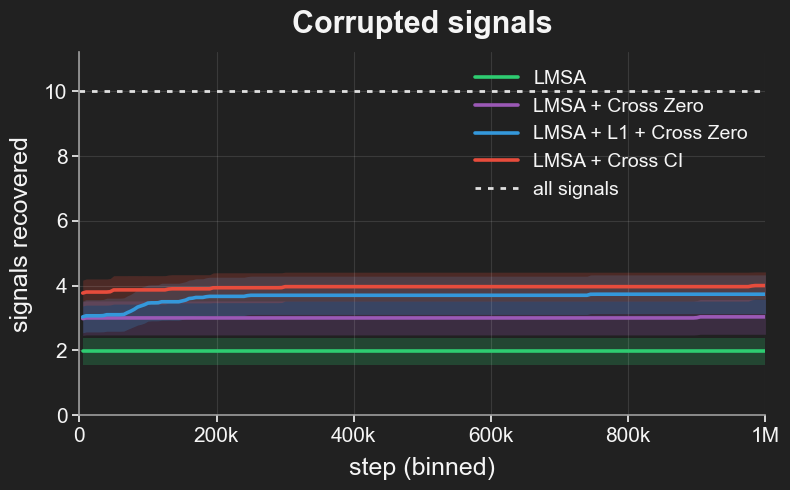

saved output/presentation/10_corrupted_signals.png


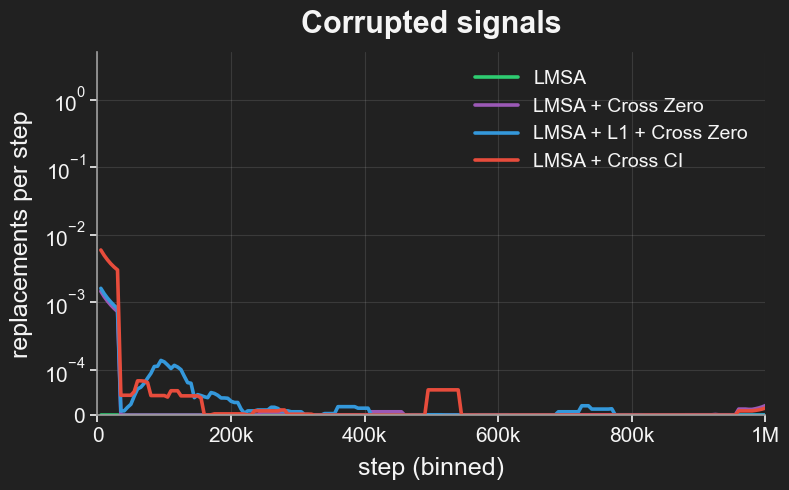

saved output/presentation/10_corrupted_replacements.png


In [39]:
performance_figures(10, 'corrupted', ALL_METHODS, 'corrupted');

## Figure 11: coverage by signal size

The figure 9 runs, read a different way: which signals a method is holding at the end of the run, by the
signal's weight in the target. The dotted line is the weight below which an L1 penalty drives a real signal
back to zero, `L1_COEFF / E[x^2]`; the coverage of every method is the mean over the last bin of the run.

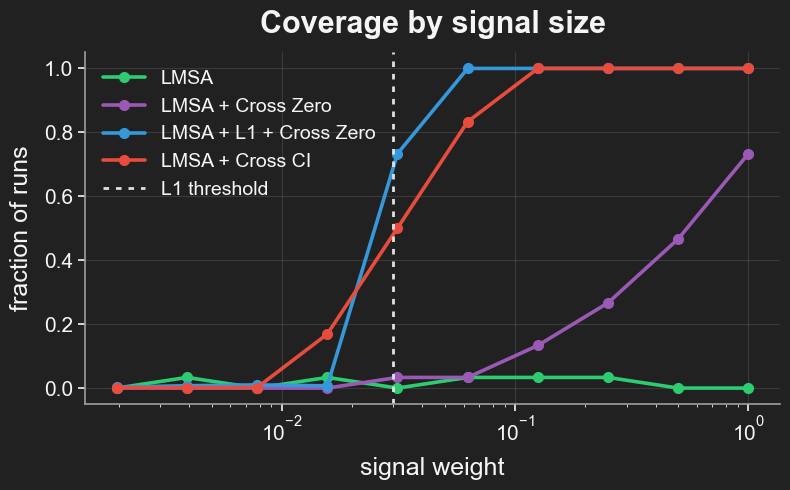

saved output/presentation/11_coverage_by_size.png


In [40]:
def coverage_by_size_figure(number, name, method_keys, problem_key):
    """How often each signal is covered at the end of the run, against the signal's weight in the target."""
    results = {m: results_for(m, problem_key) for m in method_keys}
    fig, ax = new_figure(TITLES[name], AXIS_LABELS['fraction_runs'])
    for m, res in results.items():
        final = res['signals'][:, -1, :]                       # (seeds, signals), over the last bin
        line(ax, TARGET_WEIGHTS_DECAY, final.mean(0), COLORS[m], LABELS[m], marker='o', ms=7)
    if SHOW_L1_THRESHOLD_LINE:
        ax.axvline(L1_THRESHOLD, color=BOUND_COLOR, ls=(0, (2, 2.5)), lw=2, label=LABELS['l1_threshold'])
    ax.set_xscale('log')
    ax.set_xlabel(AXIS_LABELS['signal_weight'])
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc=LEGEND_LOC)
    save(fig, f'{number:02d}_{name}')
    return results


coverage_by_size_figure(11, 'coverage_by_size', ALL_METHODS, 'decaying_3m');